Ejercicio 1.- Evolución de una población de aves.
-------

Estamos haciendo el seguimiento de las hembras de cierta especie de aves, que clasificamos en tres clases de edad:</span>

- Jóvenes: de 0 a 1 año.

- Adultas fértiles: de 1 a 2 años de edad.

- Adultas no fértiles: de 2 a 3 años de edad.

Cada año hacemos un censo del que resulta que:

- Un 12% de las hembras jóvenes y un 54% de las adultas fértiles sobreviven cada año. Ninguna de las adultas no fértiles sobrevive.
- Cada hembra joven produce (en promedio) 0.83 hembras al año y cada adulta fértil produce dos.

**(a)** Escribe una matriz **$\texttt{matriz}\_\texttt{Aves}$** que modele la evolución de esta población de un año a otro y encuentra sus autovalores.

In [1]:
#(a) 

matriz_Aves=matrix(QQ,[[0.83,2,0],[0.12,0,0],[0,0.54,0.]])
show(matriz_Aves)
autovalores=matriz_Aves.eigenvalues()

[83/100      2      0]
[  3/25      0      0]
[     0  27/50      0]

In [2]:
# Cargamos la función que creamos en la sesión que devuelve
# el autovalor dominante (cuando lo hay)

def AutovalorDominante(M):
    autovalores=M.eigenvalues()
    AbsAutov=[abs(autovalor) for autovalor in autovalores]
    dominante=max(AbsAutov)##Valor absoluto del candidato a dominante, lo es si es simple y único en AbsAutov
    Dominante=autovalores[AbsAutov.index(dominante)]##Candidato, con su signo, a dominante
    simple=bool(dim((M-Dominante*identity_matrix(QQ,M.nrows())).right_kernel())==1)
    unico=bool(AbsAutov.count(dominante)==1)
    real_positivo=bool(Dominante in RR and Dominante>0)
    if simple and unico and real_positivo:
        return Dominante
    return None#solo se llega aquí si no hay Dominante

In [3]:
# Veamos cuál es el autovalor dominante

AutovalorDominante(matriz_Aves)

1.057047506030512?

**(b)** En el apartado anterior deberíamos haber visto que el autovalor dominante de la matriz es aproximadamente 1.057, lo que supone que, en esas condiciones, la población crecerá a largo plazo una 5.7% anual. Para comprobarlo, simula la evolución de la población a lo largo de 50 años a partir de un momento inicial en el que hay 100 hembras de cada clase de edad y dibuja un gráfico que muestre la evolución anual del tanto por ciento de crecimiento del número  total de hembras.

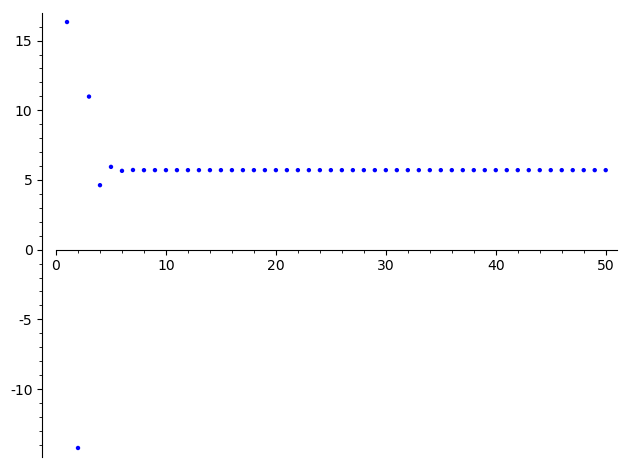

In [4]:
#(b)
v=vector([100, 100, 100])
porcentajes=[]
for k in [1..50]:
    Anterior=sum(v)
    v=matriz_Aves*v
    porcentajes+=[(k,((sum(v)/Anterior)-1)*100)]
points(porcentajes)

**(c)** Para que la especie no crezca incontroladamente, pero tampoco se extinga, permitimos la caza de hembras jóvenes.

¿Qué tasa de supervivencia $p$ de hembras jóvenes debemos conseguir para que la población total de hembras de la especie se mantenga estable a largo plazo?

In [22]:
# (c) Ponemos p como un parámetro y calculamos el polinomio 
# característico 

var('p')
assume(p>0) 
Mp=matrix([[83/100,2,0],[p,0,0],[0,54/100,0]])
P(x,p)=charpoly(Mp) # charpoly es el polinomio característico
show(Mp)
show(P(x,p))

[83/100      2      0]
[     p      0      0]
[     0  27/50      0]

x^3 - 2*p*x - 83/100*x^2

In [26]:
# Queremos que 1 sea autovalor. Buscamos un p que haga que eso
# suceda 

p0=solve(P(1,p),p)[0].rhs()
print('La tasa de supervivencia que debemos alcanzar es aproximadamente %s (%s por ciento).' %(p0,(100*p0).n(digits=3)))

La tasa de supervivencia que debemos alcanzar es aproximadamente 17/200 (8.50 por ciento).


In [27]:
# Ponemos p=p0 y comprobamos que 1 es autovalor dominante.
Mestable=matrix(QQ,Mp.substitute(p==p0))
show(Mestable)
AutovalorDominante(Mestable)

[83/100      2      0]
[17/200      0      0]
[     0  27/50      0]

1

**Ejercicio 2.- Evolución de una población de roedores**
-------

Estamos haciendo el seguimiento de las hembras de cierta especie de roedores, que clasificamos en tres clases de edad:

-Jóvenes: de 0 a 1 año.

-Adultas fecundables: de 1 a 2 años de edad.

-Adultas no fecundables: de 2 a 3 años de edad.

Cada año hacemos un censo del que resulta que:

- Las jóvenes tienen una tasa de supervivencia del 15%, y, en media, tienen cada año 0.5 crías hembra.

- Las adultas fecundables tienen una tasa de supervivencia del 54%, y, en media, tienen cada año 2 crías hembra.

- Las adultas no fecundables no tienen crías y no sobrevive ninguna.

**(a)** Escribe una matriz $\texttt{matriz}\_\texttt{Roedores}$ que modele la evolución de esta población de un año a otro y _encuentra sus autovalores_.

In [18]:
#a)
matriz_Roedores=matrix(QQ,[[0.5,2,0],[0.15,0,0],[0,0.54,0]])
show(matriz_Roedores)
matriz_Roedores.eigenvalues()

[  1/2     2     0]
[ 3/20     0     0]
[    0 27/50     0]

[0, -0.3520797289396148?, 0.8520797289396148?]

In [19]:
# Veamos cuál es el autovalor dominante
dominante=AutovalorDominante(matriz_Roedores)
dominante

0.8520797289396148?

**(b)** En el apartado anterior vemos que los autovalores de la matriz son reales y de valor absoluto $<1$, lo que supone que, en esas condiciones, la población se extinguirá. Para ver lo que pasará sin necesidad de esperar a que suceda, **simula la evolución de la población a lo largo de 50 años** a partir de un momento inicial en el que hay 100 hembras de cada clase de edad y dibuja un gráfico que muestre el número <b><span style="color: #ff0000;">total</span></b> (sumadas las tres clases de edad) de hembras en cada uno de los 51 censos (incluido el inicial).

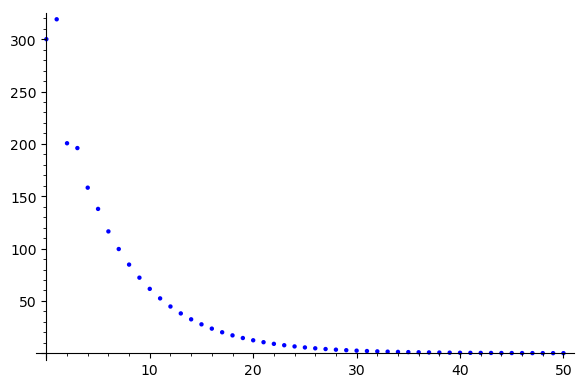

In [20]:
#b)
v=vector([100, 100, 100])
Lista=[(0,sum(v))]
for k in [1..50]:
    v=matriz_Roedores*v
    Lista+=[(k,sum(v))]
points(Lista)

**(c)** Queremos hacer algo para que la especie no se extinga, pero tampoco crezca incontroladamente. Resulta que en el ecosistema hay un predador que ataca a las hembras jóvenes, por lo que, controlando el número de ejemplares de este predador, podemos controlar también la población de hembras jóvenes y, con ellas, la población total. **¿Qué tasa de supervivencia $p$ de hembras jóvenes debemos conseguir para que la población total de hembras de la especie se mantenga estable a largo plazo?**

In [28]:
# (c) Ponemos p como un parámetro y calculamos el polinomio 
# característico 

var('p')
assume(p>0) 
Mp=matrix([[5/10,2,0],[p,0,0],[0,54/100,0]])
P(x,p)=charpoly(Mp) # charpoly es el polinomio característico
show(Mp)
show(P(x,p))

[  1/2     2     0]
[    p     0     0]
[    0 27/50     0]

x^3 - 2*p*x - 1/2*x^2

In [29]:
# Queremos que 1 sea autovalor. Buscamos un p que haga que eso
# suceda 

p0=solve(P(1,p),p)[0].rhs()
print('La tasa de supervivencia que debemos alcanzar es aproximadamente %s (%s por ciento).' %(p0,(100*p0).n(digits=3)))

La tasa de supervivencia que debemos alcanzar es aproximadamente 1/4 (25.0 por ciento).


In [30]:
# Ponemos p=p0 y comprobamos que 1 es autovalor dominante.
Mestable=matrix(QQ,Mp.substitute(p==p0))
show(Mestable)
AutovalorDominante(Mestable)

[  1/2     2     0]
[  1/4     0     0]
[    0 27/50     0]

1